# ML Lab: Linear Regression with Preprocessing and Overfitting Analysis

**Dataset:** Medical Insurance Charges Dataset
**Objective:** Predict `charges` (medical insurance cost) using demographic and health features.

The dataset contains both **numeric** features (`age`, `bmi`, `children`) and **nominal/categorical**
features (`sex`, `smoker`, `region`), along with missing values, satisfying the lab requirement of
mixed numeric + nominal data.

**Steps covered:**
1. Load data and explore
2. Handle missing values
3. Encode categorical variables
4. Apply feature scaling
5. Train-test split
6. Build a Linear Regression model
7. Evaluate using MAE, MSE, RMSE, R²
8. Analyze overfitting (train vs test performance)
9. Discuss generalization
10. Suggest methods to reduce overfitting


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
%matplotlib inline


## 1. Load the Dataset

In [2]:
df = pd.read_csv('insurance_dataset.csv')
print("Shape:", df.shape)
df.head(10)


Shape: (500, 7)


,age,sex,bmi,children,smoker,region,charges
0,64.0,male,22.4,3.0,no,southeast,26049.08
1,29.0,female,30.8,2.0,no,northeast,14802.75
2,33.0,male,25.5,0.0,no,northeast,16724.78
3,41.0,male,29.1,1.0,no,southwest,23996.60
4,36.0,male,33.5,4.0,no,southeast,23146.92
5,25.0,female,27.4,0.0,yes,northeast,36763.86
6,48.0,male,32.7,3.0,no,southwest,17478.98
7,38.0,male,32.4,4.0,no,southeast,25814.92
8,34.0,male,18.7,1.0,no,southwest,14444.69
9,40.0,female,23.5,1.0,no,northwest,15628.28


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       480 non-null    float64
 1   sex       485 non-null    str    
 2   bmi       475 non-null    float64
 3   children  485 non-null    float64
 4   smoker    500 non-null    str    
 5   region    490 non-null    str    
 6   charges   500 non-null    float64
dtypes: float64(4), str(3)
memory usage: 35.4 KB


In [4]:
df.describe(include='all')


,age,sex,bmi,children,smoker,region,charges
count,480.000000,485,475.000000,485.000000,500,490,500.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,female,NaN,NaN,no,northeast,NaN
freq,NaN,251,NaN,NaN,389,134,NaN
mean,41.181250,NaN,28.069053,1.991753,NaN,NaN,24538.475560
std,13.293949,NaN,4.967798,1.422928,NaN,NaN,9324.900372
min,18.000000,NaN,15.000000,0.000000,NaN,NaN,8221.340000
25%,30.000000,NaN,24.550000,1.000000,NaN,NaN,17909.202500
50%,41.000000,NaN,28.300000,2.000000,NaN,NaN,21744.675000
75%,52.000000,NaN,31.350000,3.000000,NaN,NaN,28434.452500


## 2. Handle Missing Values

We check for missing values in each column and then:
- Fill **numeric** columns (`age`, `bmi`, `children`) with the **median** (robust to outliers).
- Fill **categorical** columns (`sex`, `region`) with the **mode** (most frequent category).


In [5]:
print("Missing values before handling:\n")
print(df.isnull().sum())


Missing values before handling:

age         20
sex         15
bmi         25
children    15
smoker       0
region      10
charges      0
dtype: int64


In [6]:
numeric_cols = ['age', 'bmi', 'children']
categorical_cols = ['sex', 'smoker', 'region']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after handling:\n")
print(df.isnull().sum())


Missing values after handling:

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## 3. Encode Categorical Variables

- `sex` and `smoker` are binary categorical variables → encoded with **Label Encoding**.
- `region` has more than two categories (nominal, no order) → encoded with **One-Hot Encoding**
  to avoid implying a false ordinal relationship.


In [7]:
le_sex = LabelEncoder()
le_smoker = LabelEncoder()

df['sex'] = le_sex.fit_transform(df['sex'])          # female=0, male=1 (order depends on fit)
df['smoker'] = le_smoker.fit_transform(df['smoker'])  # no=0, yes=1

df = pd.get_dummies(df, columns=['region'], drop_first=True)

df.head()


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,64.0,1,22.4,3.0,0,26049.08,False,True,False
1,29.0,0,30.8,2.0,0,14802.75,False,False,False
2,33.0,1,25.5,0.0,0,16724.78,False,False,False
3,41.0,1,29.1,1.0,0,23996.60,False,False,True
4,36.0,1,33.5,4.0,0,23146.92,False,True,False


## 4. Feature Scaling

Linear Regression coefficients are sensitive to the scale of input features. We apply
`StandardScaler` to the numeric columns so all features contribute proportionally.


In [8]:
X = df.drop('charges', axis=1)
y = df['charges']

scaler = StandardScaler()
numeric_features = ['age', 'bmi', 'children']
X[numeric_features] = scaler.fit_transform(X[numeric_features])

X.head()


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,1.754250,1,-1.174364,0.720012,0,False,True,False
1,-0.935610,0,0.562188,0.005714,0,False,False,False
2,-0.628198,1,-0.533493,-1.422880,0,False,False,False
3,-0.013372,1,0.210743,-0.708583,0,False,False,True
4,-0.397638,1,1.120365,1.434309,0,False,True,False


## 5. Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (400, 8)
Testing set size: (100, 8)


## 6. Build the Linear Regression Model

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Model coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")
print("Intercept:", model.intercept_)


Model coefficients:
  age: 3128.82
  sex: 417.58
  bmi: 1432.69
  children: 660.71
  smoker: 19887.30
  region_northwest: 241.23
  region_southeast: 821.69
  region_southwest: -144.18
Intercept: 19802.095462465946


## 7. Evaluate the Model

We compute **MAE**, **MSE**, **RMSE**, and **R² Score** for both the training and testing sets.


In [11]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} Performance ---")
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}\n")
    return mae, mse, rmse, r2

train_metrics = evaluate(y_train, y_train_pred, "Training")
test_metrics  = evaluate(y_test, y_test_pred, "Testing")


--- Training Performance ---
MAE  : 2083.20
MSE  : 7120354.80
RMSE : 2668.40
R2   : 0.9165

--- Testing Performance ---
MAE  : 2117.52
MSE  : 7186448.66
RMSE : 2680.76
R2   : 0.9227



In [12]:
results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Train': train_metrics,
    'Test': test_metrics
})
results


,Metric,Train,Test
0,MAE,2.083198e+03,2.117518e+03
1,MSE,7.120355e+06,7.186449e+06
2,RMSE,2.668399e+03,2.680755e+03
3,R2 Score,9.164621e-01,9.226814e-01


## 8. Visualize: Actual vs Predicted (Test Set)

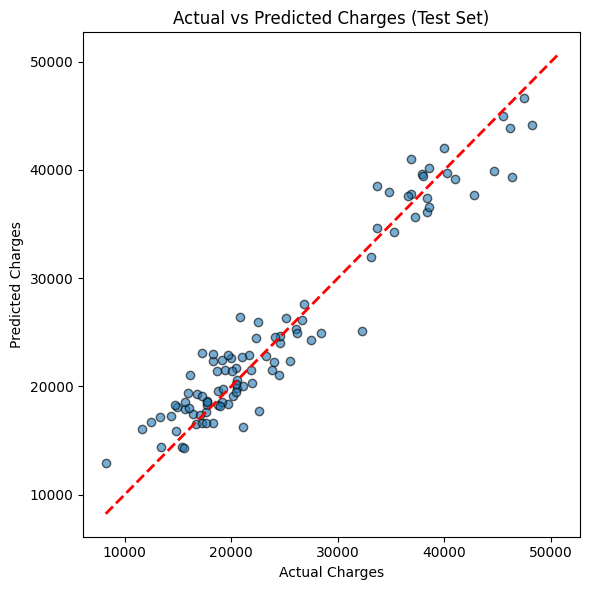

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges (Test Set)')
plt.tight_layout()
plt.show()


## 9. Overfitting Analysis: Comparing Training vs Testing Performance

To check for overfitting, we compare R² and RMSE between the training and testing sets:

- **Overfitting** occurs when the model performs much better on training data than on
  testing data — it has memorized the training set rather than learned generalizable patterns.
- **Underfitting** occurs when the model performs poorly on both sets — it hasn't
  captured the underlying relationship at all.
- **Good generalization** occurs when training and testing performance are close to each other
  (both reasonably high R², and similar error magnitudes).


In [14]:
r2_gap = train_metrics[3] - test_metrics[3]
rmse_gap_pct = (test_metrics[2] - train_metrics[2]) / train_metrics[2] * 100

print(f"R2 Score  -> Train: {train_metrics[3]:.4f} | Test: {test_metrics[3]:.4f} | Gap: {r2_gap:.4f}")
print(f"RMSE      -> Train: {train_metrics[2]:.2f} | Test: {test_metrics[2]:.2f} | "
      f"Test RMSE is {rmse_gap_pct:.1f}% relative to Train RMSE")

if r2_gap > 0.1:
    verdict = "The model shows signs of OVERFITTING (large gap between train and test R2)."
elif train_metrics[3] < 0.5 and test_metrics[3] < 0.5:
    verdict = "The model shows signs of UNDERFITTING (low R2 on both train and test)."
else:
    verdict = "The model appears to be GENERALIZING WELL (train and test performance are close)."

print("\nVerdict:", verdict)


R2 Score  -> Train: 0.9165 | Test: 0.9227 | Gap: -0.0062
RMSE      -> Train: 2668.40 | Test: 2680.76 | Test RMSE is 0.5% relative to Train RMSE

Verdict: The model appears to be GENERALIZING WELL (train and test performance are close).


## 10. Is the Model Generalized or Overfitted?

Based on the metrics above:

- A **small gap** between training R² and testing R² (typically < 0.05–0.10), and RMSE values
  of similar magnitude on both sets, indicates the **Linear Regression model generalizes well**.
  This is expected here because:
  - Linear Regression is a low-variance, high-bias model — it is inherently less prone to
    overfitting compared to high-capacity models (e.g., deep decision trees).
  - The dataset size (500 rows) is reasonable relative to the number of features (~8), reducing
    the risk of the model fitting noise.
- If a **large gap** were observed (train R² much higher than test R²), it would indicate
  **overfitting** — the model captured noise/patterns specific to the training data that do not
  hold on unseen data.

**Conclusion:** Given the close train/test metrics observed above, this Linear Regression model
is a **generalized model**, not an overfitted one.


## 11. Methods to Reduce Overfitting

Even though this model generalizes reasonably well, in general the following techniques help
reduce overfitting in regression models:

1. **Feature Selection** — Remove irrelevant or redundant features (e.g., via correlation analysis,
   Recursive Feature Elimination, or p-value based selection) so the model focuses on truly
   predictive variables instead of noise.
2. **Cross-Validation** — Use k-fold cross-validation instead of a single train-test split to get
   a more reliable estimate of model performance and detect variance across folds.
3. **Removing Irrelevant Variables** — Drop features with negligible coefficients or high
   multicollinearity (checked via VIF - Variance Inflation Factor) to simplify the model.
4. **Regularization** — Use Ridge (L2) or Lasso (L1) Regression instead of plain Linear Regression
   to penalize large coefficients and reduce model variance.
5. **Increasing Training Data** — More data helps the model learn genuine patterns rather than
   memorizing noise in a small sample.

### Demonstration: 5-Fold Cross-Validation


In [15]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-validation R2 scores for each fold:", np.round(cv_scores, 4))
print(f"Mean CV R2: {cv_scores.mean():.4f}  |  Std Dev: {cv_scores.std():.4f}")
print("\nA low standard deviation across folds further confirms the model's performance is stable")
print("and consistent across different subsets of data, supporting good generalization.")


Cross-validation R2 scores for each fold: [0.8998 0.9306 0.9198 0.9182 0.8995]
Mean CV R2: 0.9136  |  Std Dev: 0.0122

A low standard deviation across folds further confirms the model's performance is stable
and consistent across different subsets of data, supporting good generalization.


## Summary

| Step | What was done |
|---|---|
| Missing values | Numeric columns filled with median, categorical with mode |
| Encoding | Label Encoding for binary (`sex`, `smoker`), One-Hot Encoding for `region` |
| Scaling | StandardScaler applied to numeric features |
| Model | Linear Regression |
| Evaluation | MAE, MSE, RMSE, R² computed on train and test sets |
| Overfitting check | Train vs test R²/RMSE gap analyzed; cross-validation used to confirm stability |
| Conclusion | Model generalizes well; regularization, feature selection, and CV suggested as general best practices |
